# Kaggle Contest: Home Credit Default Risk

Contribution:

REN, Chenyang (Student ID: 21214707): Data preprocessing and model tuning

WEI, Yupeng (Student ID: 21130171): Exploratory data analysis

YANG, Ding (Student ID: 21129811): Poster preparation

Shared contributions: domain knowledge feature identification, feature engineering and verification, resolving model limitations, and performing supplementary analyses.

## Package Import

In [1]:
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from graphviz import Digraph
from IPython.display import Image
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import os
import lightgbm as lgb

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Workflow

In this project, each dataset goes through **Preprocessing** and **Feature Engineering**, but the methods differ depending on the data structure.

- **Application Data (train + test)**  
  - Each applicant corresponds to a single row.  
  - **Preprocessing**: remove anomalies (e.g., invalid `DAYS_EMPLOYED` values), handle missing values, and encode categorical variables.  
  - **Feature Engineering**: construct new ratio-based variables (e.g., credit-to-annuity, credit-to-income), document counts, and interactions between external sources.  
  - This dataset is provided separately as training and testing sets, since the test set is used for final scoring.

- **Other Datasets (all applicants)**  
  These include **Bureau & Balance, Previous Applications, POS_CASH Balance, Installments Payments, and Credit Card Balance**.  
  - Each applicant can have multiple records.  
  - **Preprocessing**: remove anomalies, handle missing values, and encode categorical variables.  
  - **Feature Engineering**: aggregate multiple records into applicant-level features using descriptive statistics such as mean, max, min, variance, and proportions. For example:  
    - Bureau & Balance: aggregate active vs. closed loans.  
    - Previous Applications: separate approved vs. refused applications.  
    - POS/Installments/Credit Card: summarize repayment behavior, overdue patterns, and credit usage.

- **Feature Merging**  
  After feature engineering, all datasets are merged into a single applicant-level dataset for modeling.

- **Model Training**  
  We trained LightGBM models with K-Fold cross-validation, addressed class imbalance, and analyzed feature importance.

- **Results & Submission**  
  Finally, we evaluated model performance using AUC and generated the submission file for the competition.


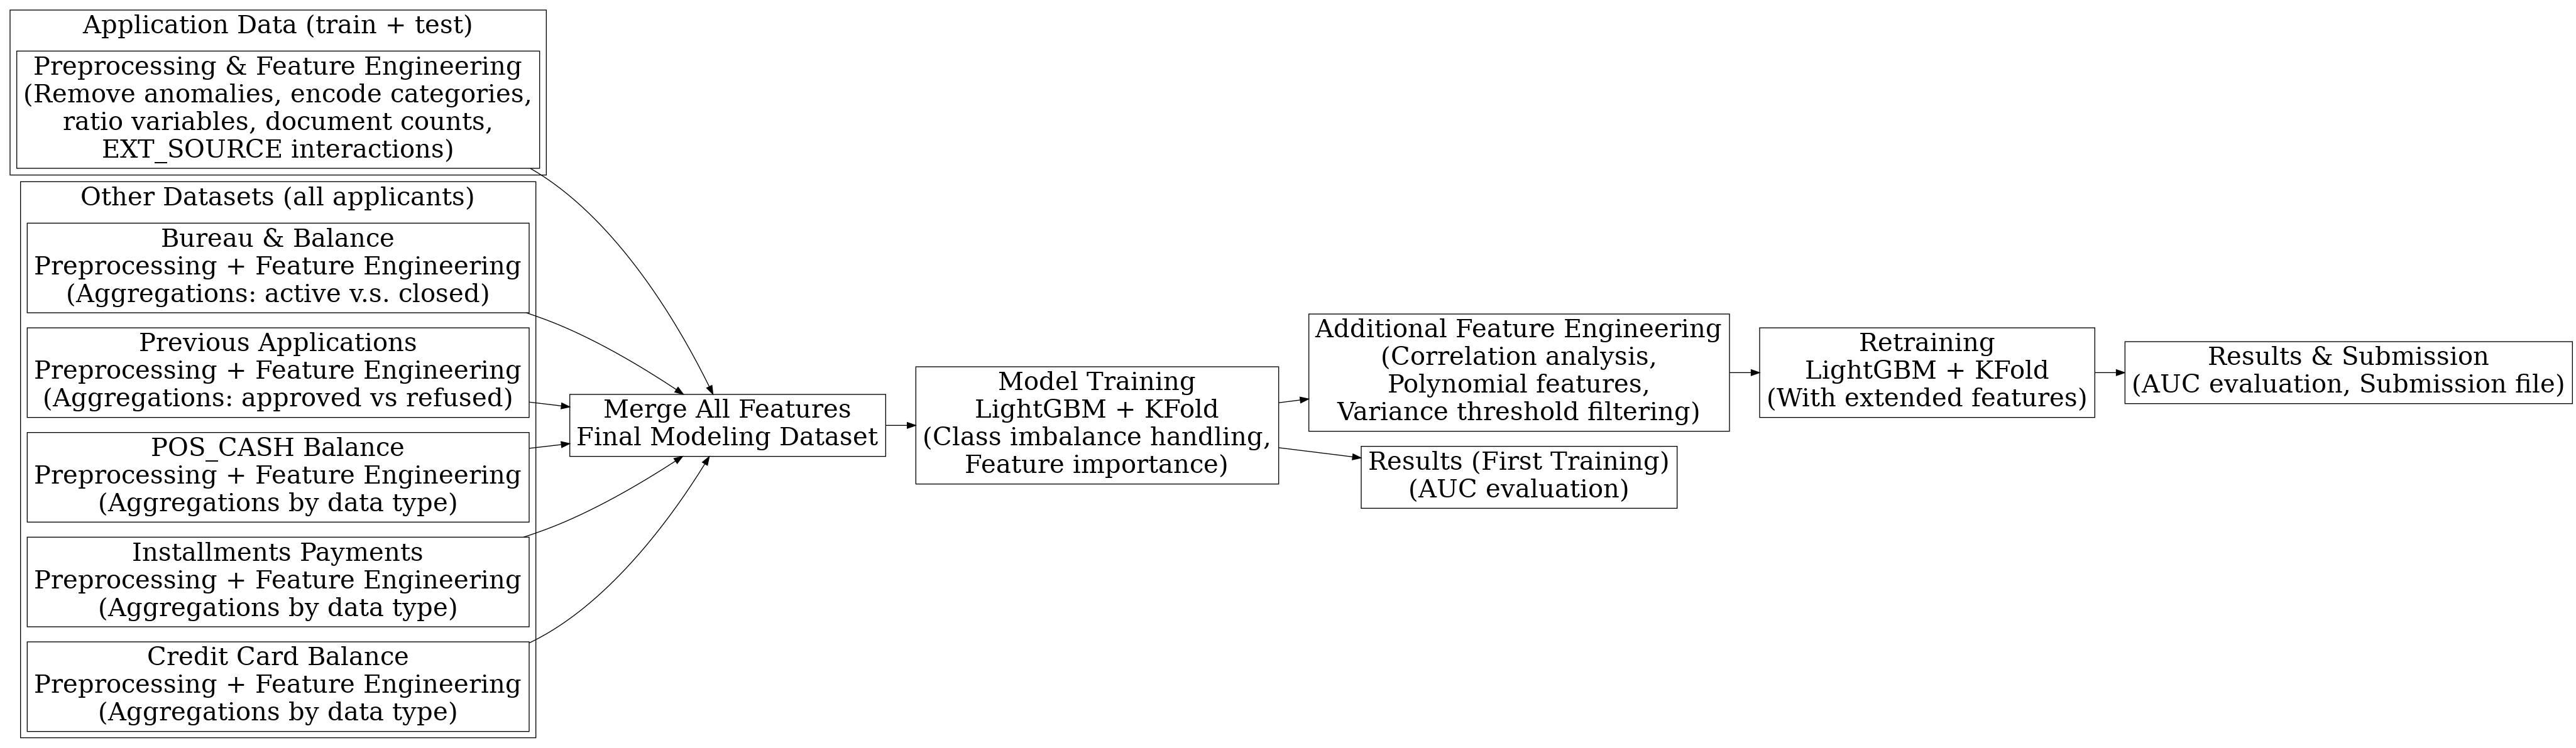

In [2]:
dot = Digraph(comment='Home Credit Project Workflow')
dot.attr(rankdir='LR')  # Left-to-right layout
dot.attr('node', shape='box', fontsize='30')

# Application dataset
with dot.subgraph(name='cluster_app') as a:
    a.attr(label='Application Data (train + test)', fontsize='30')
    a.node('A1', 'Preprocessing & Feature Engineering\n(Remove anomalies, encode categories,\nratio variables, document counts,\nEXT_SOURCE interactions)')

# Other datasets (merged preprocessing + feature engineering)
with dot.subgraph(name='cluster_other') as c:
    c.attr(label='Other Datasets (all applicants)', fontsize='30')
    
    c.node('B', 'Bureau & Balance\nPreprocessing + Feature Engineering\n(Aggregations: active v.s. closed)')
    c.node('P', 'Previous Applications\nPreprocessing + Feature Engineering\n(Aggregations: approved vs refused)')
    c.node('POS', 'POS_CASH Balance\nPreprocessing + Feature Engineering\n(Aggregations by data type)')
    c.node('I', 'Installments Payments\nPreprocessing + Feature Engineering\n(Aggregations by data type)')
    c.node('CC', 'Credit Card Balance\nPreprocessing + Feature Engineering\n(Aggregations by data type)')

# Merge
dot.node('M', 'Merge All Features\nFinal Modeling Dataset')

# Modeling (two stages)
dot.node('E1', 'Model Training\nLightGBM + KFold\n(Class imbalance handling,\nFeature importance)')
dot.node('FE_extra', 'Additional Feature Engineering\n(Correlation analysis,\nPolynomial features,\nVariance threshold filtering)')
dot.node('E2', 'Retraining\nLightGBM + KFold\n(With extended features)')

# Outputs
dot.node('F1', 'Results (First Training)\n(AUC evaluation)')
dot.node('F2', 'Results & Submission\n(AUC evaluation, Submission file)')

# Connections
dot.edge('A1', 'M')
dot.edge('B', 'M')
dot.edge('P', 'M')
dot.edge('POS', 'M')
dot.edge('I', 'M')
dot.edge('CC', 'M')

dot.edge('M', 'E1')
dot.edge('E1', 'FE_extra')
dot.edge('E1', 'F1')        # 新增：第一次训练直接输出结果
dot.edge('FE_extra', 'E2')
dot.edge('E2', 'F2')

dot.render('workflow', format='png', cleanup=True)
Image(filename='workflow.png', width=1000)


## Preparation function
We first defined a function to compute the running time,

In [3]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))

### One-Hot Encoding with Missing Values

Then defined a function `one_hot_encoder` to re-encode categorical variables. Considering that missing values `NaN` may also contain some information, we allow data with `NaN` to be treated as a separate category. 

In [4]:
# One-hot encoding for categorical columns with get_dummies
def one_hot_encoder(df, nan_as_category = True):
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns= categorical_columns, dummy_na= nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

The `one_hot_encoder` function transforms a categorical column into multiple binary (0-1) columns.  
Here is a simple example below, a column containing **three categories** and some **`NaN` values** is expanded into **four columns**.  

- Each new column represents one possible category.  
- A value of `1` indicates membership in that category, while `0` indicates otherwise.  
- Missing values (`NaN`) are treated as an additional category, ensuring no information is lost.


In [5]:
data_demonstrate = {
    'Color': ['Red', 'Blue', 'Green', np.nan, 'Blue']
}

df_demonstrate = pd.DataFrame(data_demonstrate)
print("Original DataFrame:")
print(df_demonstrate)

# 使用 one_hot_encoder
df_demonstrate_encoded, new_cols = one_hot_encoder(df_demonstrate, nan_as_category=True)
print("\nOne-hot Encoded DataFrame:")
print(df_demonstrate_encoded)

print("\nNew columns created by one-hot encoding:")
print(new_cols)

Original DataFrame:
   Color
0    Red
1   Blue
2  Green
3    NaN
4   Blue

One-hot Encoded DataFrame:
   Color_Blue  Color_Green  Color_Red  Color_nan
0       False        False       True      False
1        True        False      False      False
2       False         True      False      False
3       False        False      False       True
4        True        False      False      False

New columns created by one-hot encoding:
['Color_Blue', 'Color_Green', 'Color_Red', 'Color_nan']


## Exploratory data analysis and Feature engineering

### Processing Application Data

Firstly, merging the training and testing datasets to facilitate unified feature engineering.

By examining the distributions of key variables, we identified several anomalies in the application dataset.  
- For **`DAYS_BIRTH`**, some values were missing (`NaN`). Since these do not provide useful information, we removed them to avoid introducing noise.  
- For **`DAYS_EMPLOYED`**, we observed a large number of entries equal to **365243**, which is clearly an invalid placeholder.  

To address these issues, we replaced the anomalous values with `NaN` and categorize this variable into employment duration groups as  **`NEW_DAYS_EMPLOYED_CAT`**. This step both reduced noise and added potentially informative structure to the data.  

CODE_GENDER
F      235126
M      121125
XNA         4
Name: count, dtype: int64


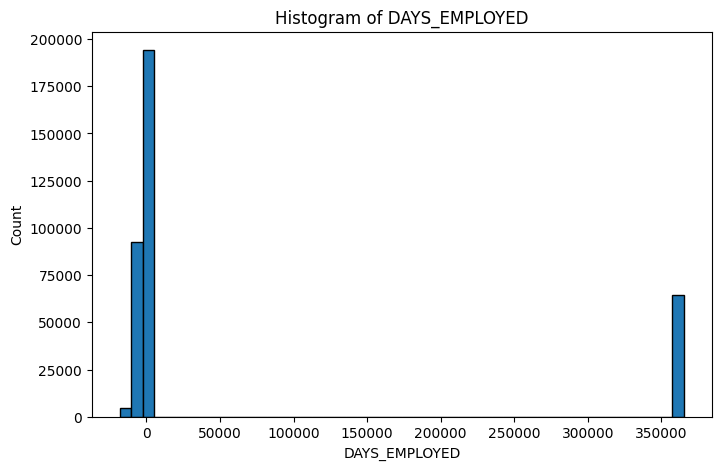

In [6]:
df = pd.read_csv('../input/application_train.csv')
test_df = pd.read_csv('../input/application_test.csv')
df = pd.concat([df, test_df]).reset_index()
print(df['CODE_GENDER'].value_counts(dropna=False))
plt.figure(figsize=(8, 5))
plt.hist(df['DAYS_EMPLOYED'], bins=50, edgecolor='black')
plt.title('Histogram of DAYS_EMPLOYED')
plt.xlabel('DAYS_EMPLOYED')
plt.ylabel('Count')
plt.show()

### Feature Engineering for Application Data

In order to better capture the financial profile of loan applicants, we construct a variety of new features that are widely used in **credit risk modeling**. These features are designed to reveal an applicant’s **repayment ability**, **financial stress**, **asset structure**, and **overall credit risk**.

#### 1. ratio features

For example, we construct a new feature **`NEW_CREDIT_TO_ANNUITY_RATIO`**, 
```python
df['NEW_CREDIT_TO_ANNUITY_RATIO'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
```

- **Interpretation:**  
  - A **higher ratio** suggests a longer repayment period or lower interest rate.
  - A **lower ratio** implies a shorter term or heavier monthly payment burden.

Similarly, we create many other ratio-based features, where the denominators often include:
- **`DAYS_BIRTH`** -> age
- **`DAYS_EMPLOYED`** -> employment duration
- **`AMT_INCOME_TOTAL`** -> and income

This allows us to standardize information across applicants on a comparable scale.

#### 2. Aggregated Indicator Variable

We also construct an **aggregated indicator feature** from the document submission variables.  

The dataset contains multiple binary indicators (**`FLAG_DOCUMENT_{2-21}`**) that record whether specific documents were provided by the applicant.  

- **Construction:** We sum these indicators to form a new variable **`NEW_DOC_TOTAL_NUMBERS`**.  
- **Interpretation:**  
  - A **higher value** indicates that more documents were submitted, reflecting greater completeness and transparency.  
  - A **lower value** suggests fewer documents provided, which may imply higher uncertainty or risk.  
- **Post-processing:** After creating this aggregated feature, we remove the original document indicator variables to reduce redundancy and avoid introducing unnecessary noise.




![Discription of FLAG_DOCUMENT.png](<attachment:Discription of FLAG_DOCUMENT.png>)
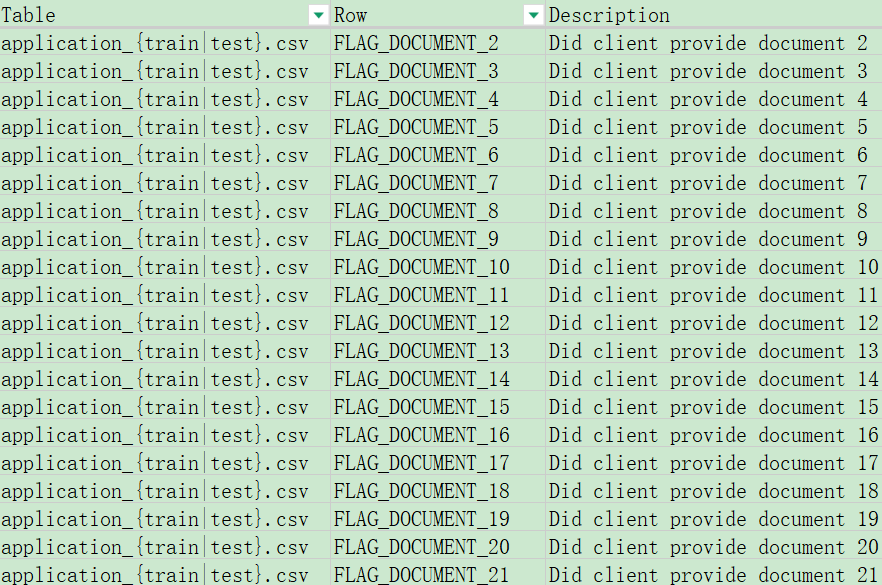

Here is the code for the work we have talked about above:

In [29]:
def categorize_days_employed(days):
    if pd.isnull(days) or days == 365243:
        return 'Unknown'
    elif days == 0:
        return 'Not Employed'
    elif -90 < days < 0:
        return 'Employed (Very Short Term)'
    elif -365 < days <= -90:
        return 'Employed (Short Term)'
    elif -730 < days <= -365:
        return 'Employed (1-2 Years)'
    elif -1825 < days <= -730:
        return 'Employed (2-5 Years)'
    elif -3650 < days <= -1825:
        return 'Employed (5-10 Years)'
    elif days <= -3650:
        return 'Employed (Long Term)'

In [32]:
def application_train_test(num_rows = None, nan_as_category = False):
    # Read data and merge
    df = pd.read_csv('../input/application_train.csv', nrows= num_rows)
    test_df = pd.read_csv('../input/application_test.csv', nrows= num_rows)
    print("Train samples: {}, test samples: {}".format(len(df), len(test_df)))
    df = pd.concat([df, test_df]).reset_index()
    df = df[df['CODE_GENDER'] != 'XNA']


    inc_by_org = df[['AMT_INCOME_TOTAL', 'ORGANIZATION_TYPE']].groupby('ORGANIZATION_TYPE').median()['AMT_INCOME_TOTAL']

    docs = [_f for _f in df.columns if 'FLAG_DOC' in _f]
    live = [_f for _f in df.columns if ('FLAG_' in _f) & ('FLAG_DOC' not in _f) & ('_FLAG_' not in _f) & (_f not in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY'])]
    asset = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
    
        
    df['NEW_CREDIT_TO_ANNUITY_RATIO'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
    df['NEW_CREDIT_TO_GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
    df['NEW_DOC_TOTAL_NUMBERS'] = df[docs].sum(axis=1)
    df['NEW_LIVE_INFORMATION'] = df[live].sum(axis=1)
    df['NEW_LIVE_ASSET'] = df[asset].apply(lambda x: (x == 'Y').sum(), axis=1).astype('object')
    df['NEW_INC_PER_CHLD'] = df['AMT_INCOME_TOTAL'] / (1 + df['CNT_CHILDREN'])
    df['NEW_INC_BY_ORG'] = df['ORGANIZATION_TYPE'].map(inc_by_org)
    df['NEW_EMPLOY_TO_BIRTH_RATIO'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['NEW_ANNUITY_TO_INCOME_RATIO'] = df['AMT_ANNUITY'] / (1 + df['AMT_INCOME_TOTAL'])
    df['NEW_SOURCES_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    df['NEW_EXT_SOURCES_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    df['NEW_SCORES_STD'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
    df['NEW_SCORES_STD'] = df['NEW_SCORES_STD'].fillna(df['NEW_SCORES_STD'].mean())
    df['NEW_CAR_TO_BIRTH_RATIO'] = df['OWN_CAR_AGE'] / df['DAYS_BIRTH']
    df['NEW_CAR_TO_EMPLOY_RATIO'] = df['OWN_CAR_AGE'] / df['DAYS_EMPLOYED']
    df['NEW_PHONE_TO_BIRTH_RATIO'] = df['DAYS_LAST_PHONE_CHANGE'] / df['DAYS_BIRTH']
    df['NEW_PHONE_TO_BIRTH_RATIO_EMPLOYER'] = df['DAYS_LAST_PHONE_CHANGE'] / df['DAYS_EMPLOYED']
    df['NEW_CREDIT_TO_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
    
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    df['DAYS_EMPLOYED_CAT'] = df['DAYS_EMPLOYED'].apply(categorize_days_employed)
    df['DAYS_EMPLOYED_CAT'] = df['DAYS_EMPLOYED_CAT'].astype('object')
    # Categorical features with Binary encode (0 or 1; two categories)
    for bin_feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        df[bin_feature], uniques = pd.factorize(df[bin_feature])
    # Categorical features with One-Hot encode
    df, cat_cols = one_hot_encoder(df, nan_as_category)
    dropcolum=['FLAG_DOCUMENT_2','FLAG_DOCUMENT_4',
    'FLAG_DOCUMENT_5','FLAG_DOCUMENT_6','FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_8','FLAG_DOCUMENT_9','FLAG_DOCUMENT_10', 
    'FLAG_DOCUMENT_11','FLAG_DOCUMENT_12','FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14','FLAG_DOCUMENT_15','FLAG_DOCUMENT_16',
    'FLAG_DOCUMENT_17','FLAG_DOCUMENT_18','FLAG_DOCUMENT_19',
    'FLAG_DOCUMENT_20','FLAG_DOCUMENT_21']
    df= df.drop(dropcolum,axis=1)
    del test_df
    gc.collect()
    return df

In [38]:

def application_train_test_for_model(num_rows = None, nan_as_category = False):
    # Read data and merge
    df = pd.read_csv('../input/application_train.csv', nrows= num_rows)
    test_df = pd.read_csv('../input/application_test.csv', nrows= num_rows)
    print("Train samples: {}, test samples: {}".format(len(df), len(test_df)))
    df = pd.concat([df, test_df]).reset_index()
    df = df[df['CODE_GENDER'] != 'XNA']


    inc_by_org = df[['AMT_INCOME_TOTAL', 'ORGANIZATION_TYPE']].groupby('ORGANIZATION_TYPE').median()['AMT_INCOME_TOTAL']

    docs = [_f for _f in df.columns if 'FLAG_DOC' in _f]
    live = [_f for _f in df.columns if ('FLAG_' in _f) & ('FLAG_DOC' not in _f) & ('_FLAG_' not in _f) & (_f not in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY'])]
    asset = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
    
        
    df['NEW_CREDIT_TO_ANNUITY_RATIO'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
    df['NEW_CREDIT_TO_GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
    df['NEW_DOC_TOTAL_NUMBERS'] = df[docs].sum(axis=1)
    df['NEW_LIVE_INFORMATION'] = df[live].sum(axis=1)
    df['NEW_LIVE_ASSET'] = df[asset].apply(lambda x: (x == 'Y').sum(), axis=1).astype('object')
    df['NEW_INC_PER_CHLD'] = df['AMT_INCOME_TOTAL'] / (1 + df['CNT_CHILDREN'])
    df['NEW_INC_BY_ORG'] = df['ORGANIZATION_TYPE'].map(inc_by_org)
    df['NEW_EMPLOY_TO_BIRTH_RATIO'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['NEW_ANNUITY_TO_INCOME_RATIO'] = df['AMT_ANNUITY'] / (1 + df['AMT_INCOME_TOTAL'])
    df['NEW_SOURCES_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    df['NEW_EXT_SOURCES_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    df['NEW_SCORES_STD'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
    df['NEW_SCORES_STD'] = df['NEW_SCORES_STD'].fillna(df['NEW_SCORES_STD'].mean())
    df['NEW_CAR_TO_BIRTH_RATIO'] = df['OWN_CAR_AGE'] / df['DAYS_BIRTH']
    df['NEW_CAR_TO_EMPLOY_RATIO'] = df['OWN_CAR_AGE'] / df['DAYS_EMPLOYED']
    df['NEW_PHONE_TO_BIRTH_RATIO'] = df['DAYS_LAST_PHONE_CHANGE'] / df['DAYS_BIRTH']
    df['NEW_PHONE_TO_BIRTH_RATIO_EMPLOYER'] = df['DAYS_LAST_PHONE_CHANGE'] / df['DAYS_EMPLOYED']
    df['NEW_CREDIT_TO_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
    
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].apply(categorize_days_employed)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].astype('object')
    # Categorical features with Binary encode (0 or 1; two categories)
    for bin_feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        df[bin_feature], uniques = pd.factorize(df[bin_feature])
    # Categorical features with One-Hot encode
    df, cat_cols = one_hot_encoder(df, nan_as_category)
    dropcolum=['FLAG_DOCUMENT_2','FLAG_DOCUMENT_4',
    'FLAG_DOCUMENT_5','FLAG_DOCUMENT_6','FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_8','FLAG_DOCUMENT_9','FLAG_DOCUMENT_10', 
    'FLAG_DOCUMENT_11','FLAG_DOCUMENT_12','FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14','FLAG_DOCUMENT_15','FLAG_DOCUMENT_16',
    'FLAG_DOCUMENT_17','FLAG_DOCUMENT_18','FLAG_DOCUMENT_19',
    'FLAG_DOCUMENT_20','FLAG_DOCUMENT_21']
    df= df.drop(dropcolum,axis=1)
    del test_df
    gc.collect()
    return df

In [35]:
df = application_train_test()

Train samples: 307511, test samples: 48744


After replacing the outliers with **`NaN`**, the distribution of **`DAYS_EMPLOYED`** becomes more reasonable.

In [37]:
def plot_column_distribution(df, column_name):

    plt.figure(figsize=(10, 6))
    sns.histplot(df[column_name], bins=50, kde=True, color='blue')
    plt.title(f"Distribution of {column_name} (excluding 365243)")
    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    plt.show()

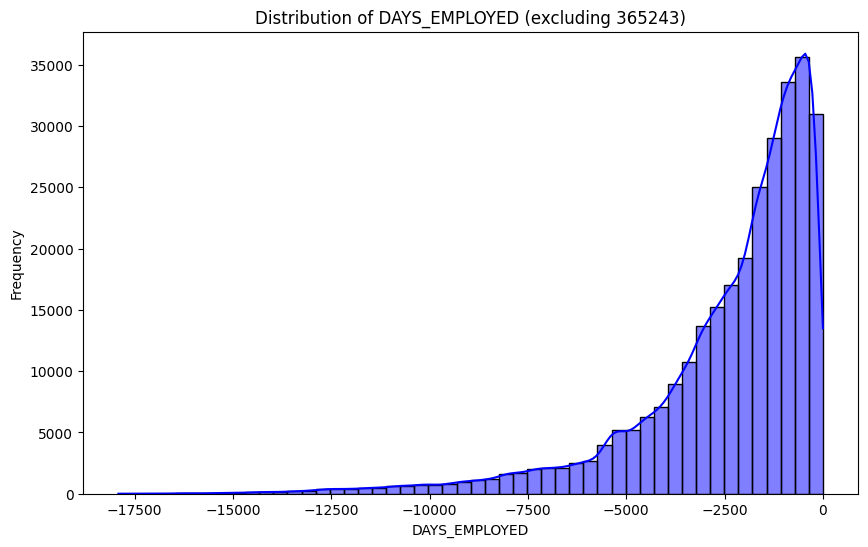

In [9]:
plot_column_distribution(df,'DAYS_EMPLOYED')

To assess the effectiveness of the newly engineered features, we plotted their **density distributions** separately for the two target classes:  
- **`TARGET == 1`** -> applicants who defaulted  
- **`TARGET == 0`** -> applicants who did not default  

The plots reveal that many of the constructed features exhibit **distinct distribution patterns** between the two groups.  
This divergence suggests that our feature engineering successfully captures meaningful differences in applicant profiles and may provide **useful predictive power** for credit risk modeling.


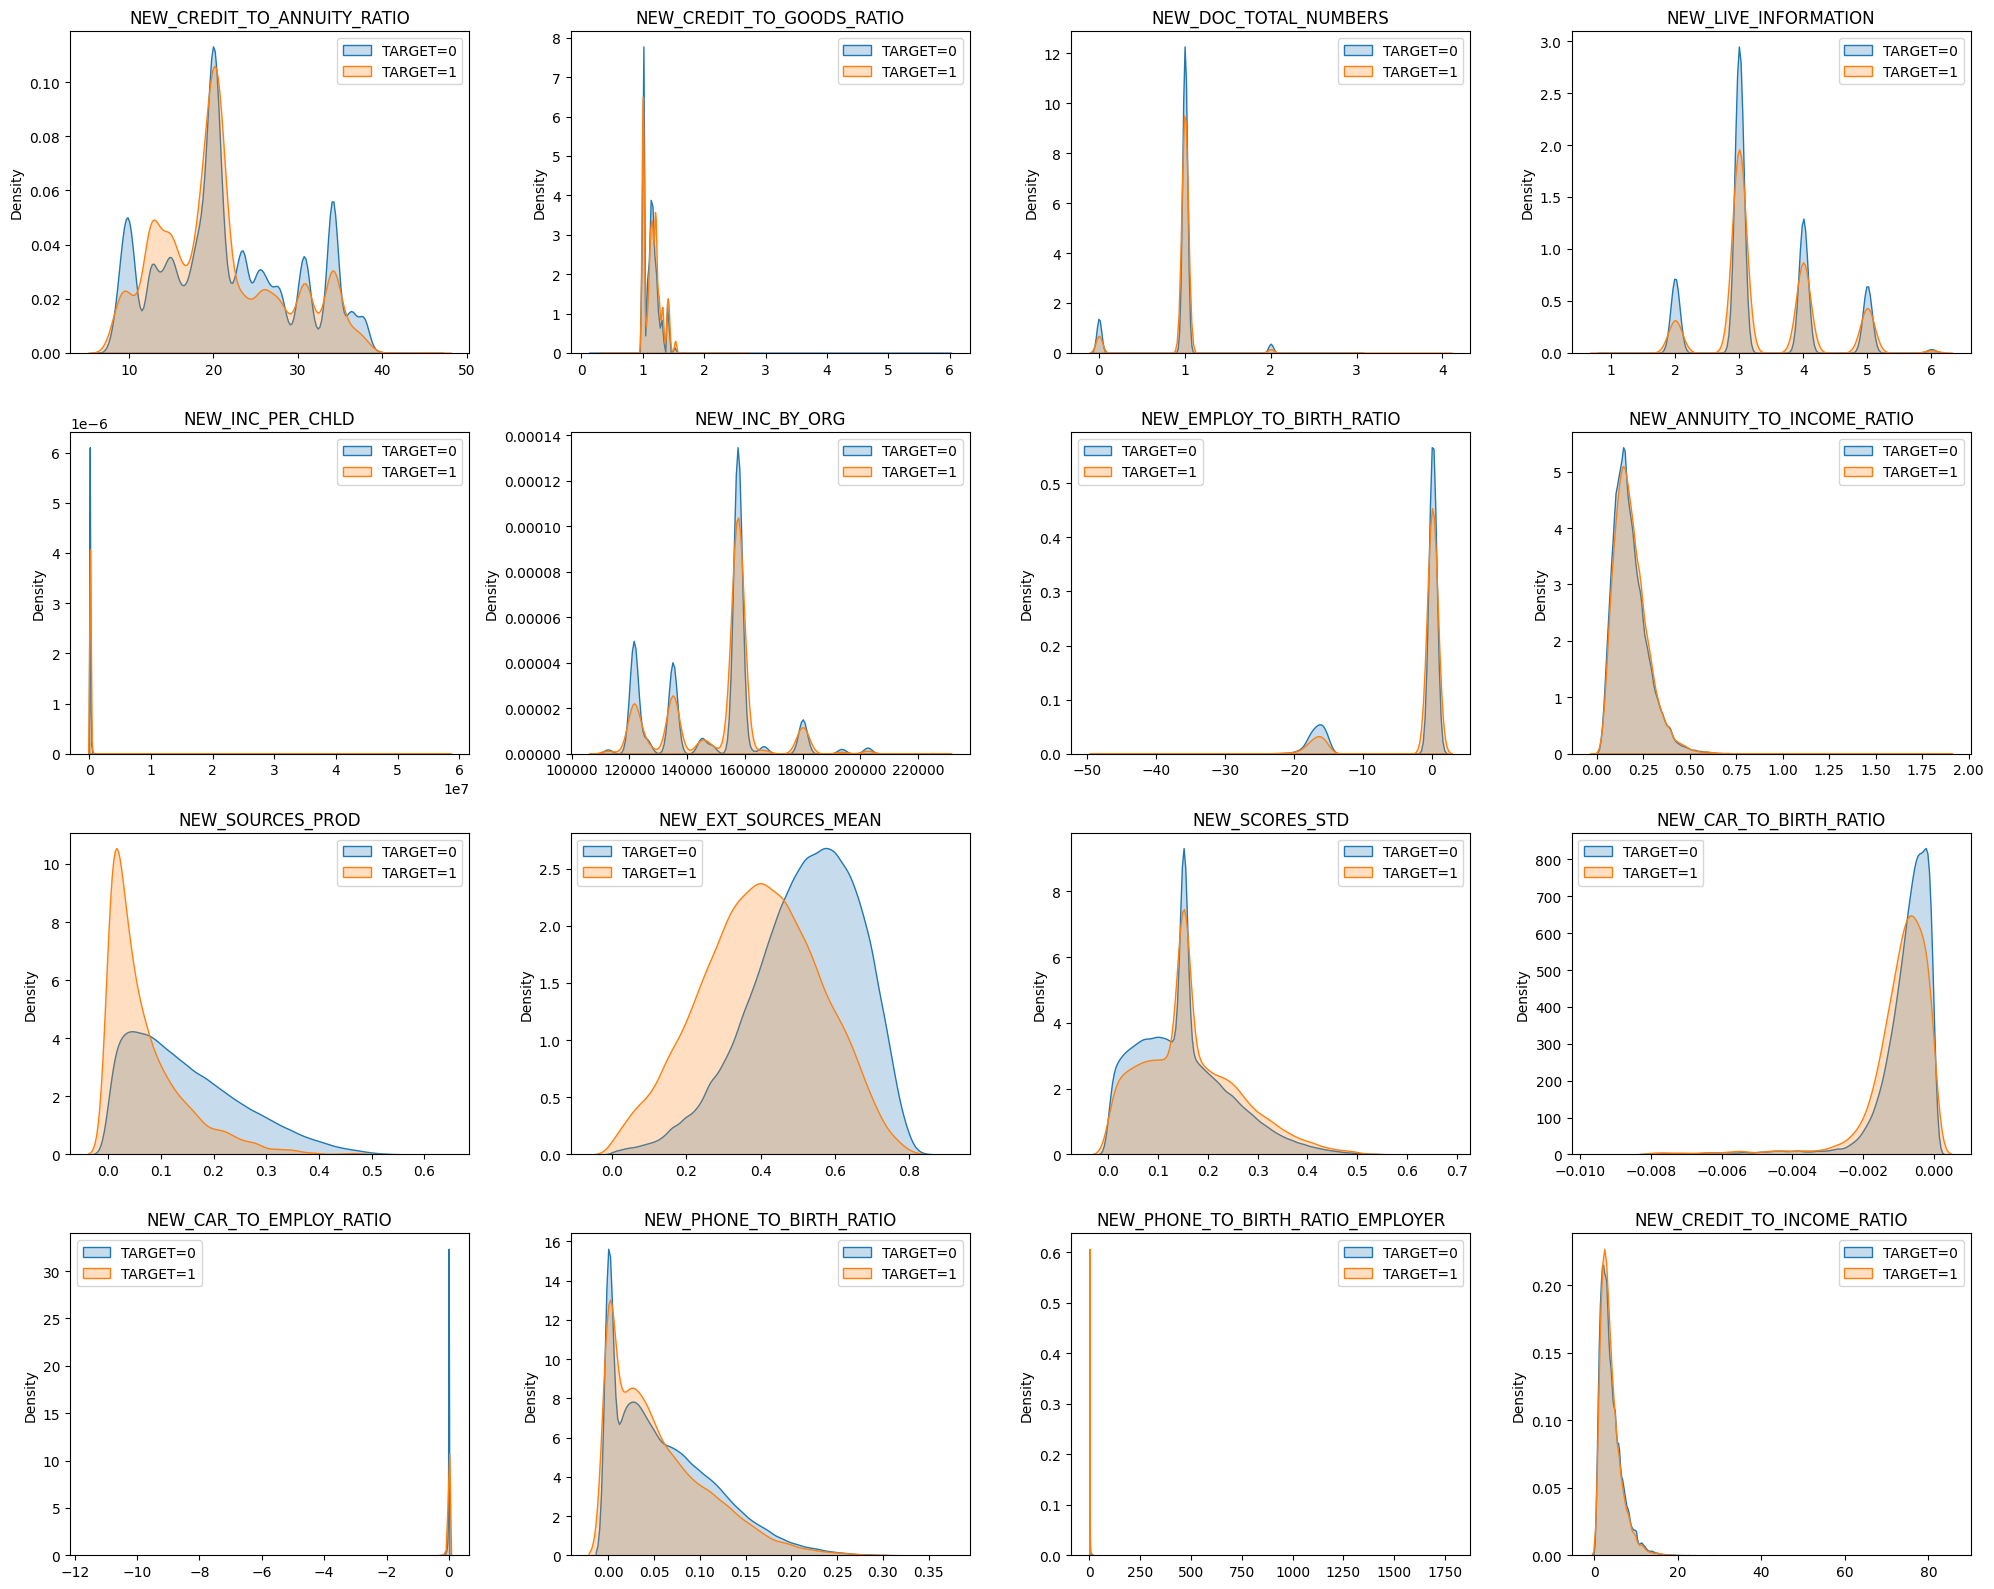

In [39]:
new_features_16 = [
    'NEW_CREDIT_TO_ANNUITY_RATIO', 'NEW_CREDIT_TO_GOODS_RATIO', 'NEW_DOC_TOTAL_NUMBERS',
    'NEW_LIVE_INFORMATION',  'NEW_INC_PER_CHLD', 'NEW_INC_BY_ORG',
    'NEW_EMPLOY_TO_BIRTH_RATIO', 'NEW_ANNUITY_TO_INCOME_RATIO', 'NEW_SOURCES_PROD',
    'NEW_EXT_SOURCES_MEAN', 'NEW_SCORES_STD', 'NEW_CAR_TO_BIRTH_RATIO', 
    'NEW_CAR_TO_EMPLOY_RATIO', 'NEW_PHONE_TO_BIRTH_RATIO', 
    'NEW_PHONE_TO_BIRTH_RATIO_EMPLOYER', 'NEW_CREDIT_TO_INCOME_RATIO'
]

# create 4x4 subplot
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, feature in enumerate(new_features_16):
    ax = axes[i]
    # KDE for TARGET=0
    sns.kdeplot(df.loc[df['TARGET']==0, feature].dropna(), label='TARGET=0', fill=True, ax=ax)
    # KDE for TARGET=1
    sns.kdeplot(df.loc[df['TARGET']==1, feature].dropna(), label='TARGET=1', fill=True, ax=ax)
    
    ax.set_title(feature)
    ax.set_xlabel('')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
# plt.savefig("new_variable_dis.pdf")
plt.show()

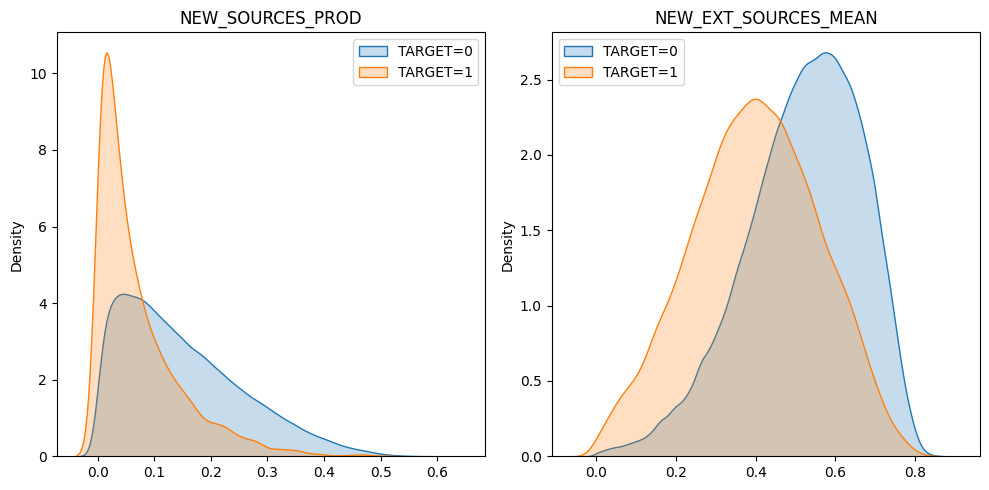

In [40]:
new_features_16 = [
    'NEW_SOURCES_PROD',
    'NEW_EXT_SOURCES_MEAN'
]

# create 4x4 subplot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()

for i, feature in enumerate(new_features_16):
    ax = axes[i]
    # KDE for TARGET=0
    sns.kdeplot(df.loc[df['TARGET']==0, feature].dropna(), label='TARGET=0', fill=True, ax=ax)
    # KDE for TARGET=1
    sns.kdeplot(df.loc[df['TARGET']==1, feature].dropna(), label='TARGET=1', fill=True, ax=ax)
    
    ax.set_title(feature)
    ax.set_xlabel('')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig("distinct_distri.pdf")
plt.show()

### Processing Bureau and Balance Data

The files **`bureau.csv`** and **`bureau_balance.csv`** provide detailed information on applicants' past credit behavior and risk history.  

- **`bureau.csv`**  
  Contains each applicant’s historical credit behavior, credit risk features, credit types, and credit limits.  
  These variables reveal:  
  - Activity in past loans  
  - Debt levels  
  - Repayment pressure  
  - Behavioral differences across different credit types  

- **`bureau_balance.csv`**  
  Provides **time-series information** for each credit record, which helps analyze:  
  - Repayment habits  
  - Evolution of credit risk over time  

using one-hot encoding for data processing.

---
### Feature Engineering for Bureau and Balance Data

- In **`bureau.csv`**, one applicant (`SK_ID_CURR`) may correspond to **multiple historical credit records** (`SK_BUREAU_ID`).  
- In **`bureau_balance.csv`**, each credit record (`SK_BUREAU_ID`) may contain **multiple time-series entries**.  

Therefore, to fully utilize the information from both datasets:  
1. We first **aggregate by `SK_BUREAU_ID`** (credit record level).  
2. Then we **aggregate by `SK_ID_CURR`** (applicant level).  

The following function performs feature engineering on:  
- **`bureau.csv`** (credit history)  
- **`bureau_balance.csv`** (monthly credit balance)  

It compresses multiple credit records into a **single applicant-level comprehensive credit feature set**, enabling downstream models to capture applicants’ past credit activity, repayment behavior, and evolving risk profile.

We use **descriptive statistics** to aggregate credit records, each with clear financial interpretation:

1. **Sum** -> captures total debt or credit, reflecting overall burden.  
2. **Mean** -> shows average levels (e.g., overdue days, credit limit), reducing outlier impact.  
3. **Max / Min** -> highlight extremes such as longest loan, largest overdue, or earliest credit history.  
4. **Variance / Std** -> measure fluctuations, indicating stability of credit behavior.  
5. **Proportion (from one-hot means)** → frequency of certain statuses (e.g., overdue, active), reflecting risk frequency and activity.

Why These Indicators?

- **Simple, interpretable, effective**  
- Cover four key dimensions: **total amount, central tendency, extremes, stability**  
- Provide essential signals for predicting default and credit risk.

Besides that, we performed numerical aggregations separately for records where the **`CREDIT_ACTIVE`** variable is “Active” and “Closed.”

- **Active credits** -> current loans still being repaid, reflecting present debt and repayment pressure.  
- **Closed credits** -> past loans already settled, reflecting historical repayment behavior.  

Separating them helps capture both **current risk** and **past credit habits**.

In [12]:
# Preprocess bureau.csv and bureau_balance.csv
def bureau_and_balance(num_rows = None, nan_as_category = True):
    bureau = pd.read_csv('../input/bureau.csv', nrows = num_rows)
    bb = pd.read_csv('../input/bureau_balance.csv', nrows = num_rows)
    bb, bb_cat = one_hot_encoder(bb, nan_as_category)
    bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category)
    
    # Bureau balance: Perform aggregations and merge with bureau.csv
    bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}
    for col in bb_cat:
        bb_aggregations[col] = ['mean']
    bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggregations)
    bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])
    bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
    bureau.drop(['SK_ID_BUREAU'], axis=1, inplace= True)
    del bb, bb_agg
    gc.collect()
    
    # Bureau and bureau_balance numeric features
    num_aggregations = {
        # example
        # 'DAYS_CREDIT': [ 'mean', 'var'],
        'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
        # 'DAYS_CREDIT_ENDDATE': [ 'mean'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_UPDATE': ['mean'],
        'CREDIT_DAY_OVERDUE': ['mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM': [ 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': [ 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
        'AMT_ANNUITY': ['max', 'mean'],
        'CNT_CREDIT_PROLONG': ['sum'],
        'MONTHS_BALANCE_MIN': ['min'],
        'MONTHS_BALANCE_MAX': ['max'],
        'MONTHS_BALANCE_SIZE': ['mean', 'sum']
    }
    # Bureau and bureau_balance categorical features
    cat_aggregations = {}
    for cat in bureau_cat: cat_aggregations[cat] = ['mean']
    for cat in bb_cat: cat_aggregations[cat + "_MEAN"] = ['mean']
    
    bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    bureau_agg.columns = pd.Index(['BURO_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
    
    # Bureau: Active credits - using only numerical aggregations
    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggregations)
    active_agg.columns = pd.Index(['ACTIVE_' + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(active_agg, how='left', on='SK_ID_CURR')
    del active, active_agg
    gc.collect()
    
    # Bureau: Closed credits - using only numerical aggregations
    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggregations)
    closed_agg.columns = pd.Index(['CLOSED_' + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(closed_agg, how='left', on='SK_ID_CURR')
    del closed, closed_agg, bureau
    gc.collect()
    return bureau_agg


In [13]:
df = bureau_and_balance()

In [14]:
def clip_nonzero_outliers(series, lower=0.01, upper=0.99):
    nonzero = series[series != 0]
    if len(nonzero) > 0:
        q_low, q_high = nonzero.quantile([lower, upper])
        series = series.clip(lower=q_low, upper=q_high)
    return series

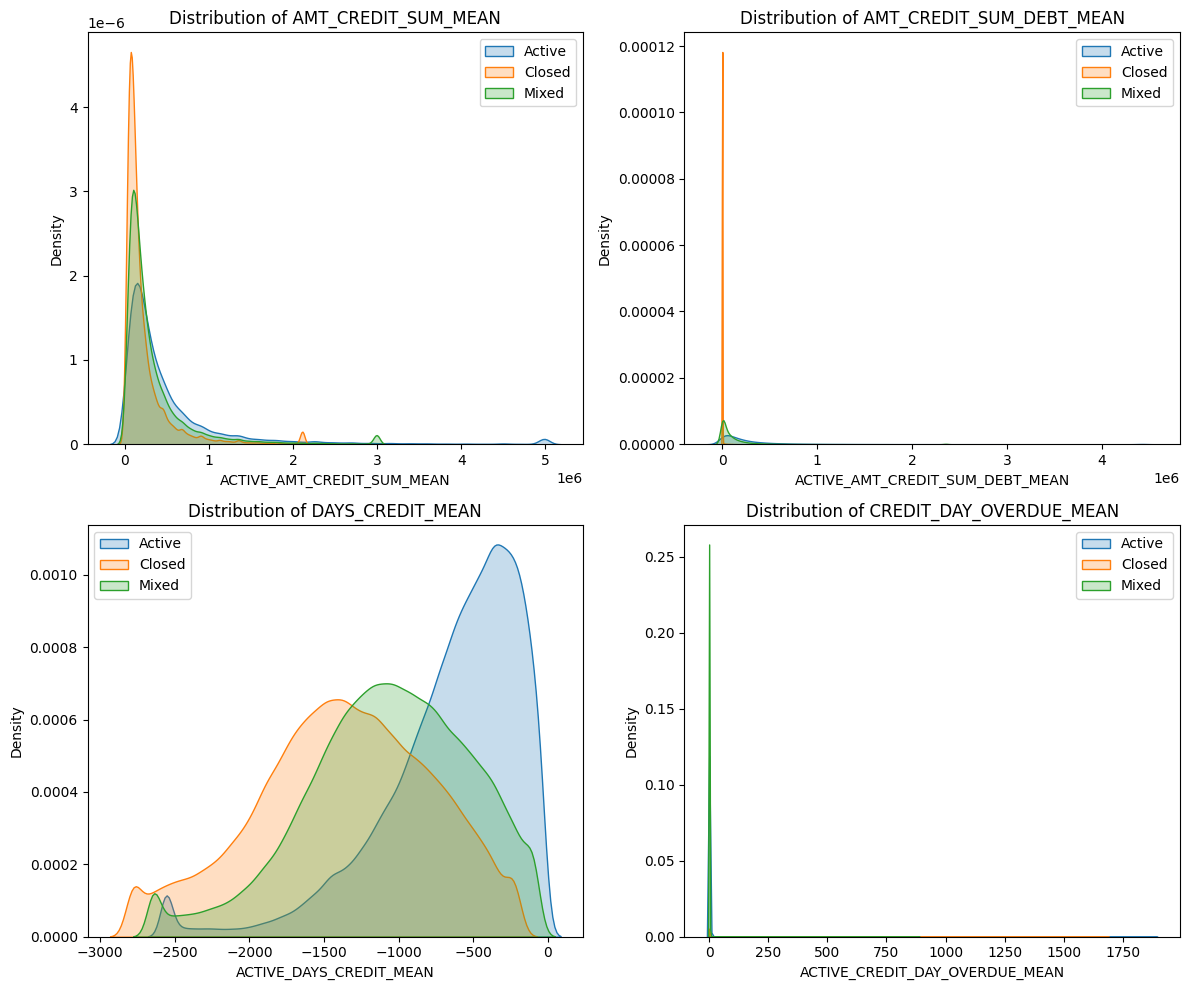

In [15]:
active_cols = [col for col in df.columns if col.startswith('ACTIVE_')]
closed_cols = [col for col in df.columns if col.startswith('CLOSED_')]

features_to_plot = [
    'AMT_CREDIT_SUM_MEAN',
    'AMT_CREDIT_SUM_DEBT_MEAN',
    'DAYS_CREDIT_MEAN',
    'CREDIT_DAY_OVERDUE_MEAN'
]

plt.figure(figsize=(12, 10))
for i, feat in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.kdeplot(
    clip_nonzero_outliers(df[f'ACTIVE_{feat}']),
    label='Active',
    fill=True
    )
    sns.kdeplot(
    clip_nonzero_outliers(df[f'CLOSED_{feat}']),
    label='Closed',
    fill=True
    )
    sns.kdeplot(
    clip_nonzero_outliers(df[f'BURO_{feat}']),
    label='Mixed',
    fill=True
    )
    plt.title(f'Distribution of {feat}')
    plt.legend()
plt.tight_layout()
plt.show()

### Processing Previous Applications Data
The file **`previous_application.csv`** contains clients’ historical loan applications.  
- Each row = one past application (`SK_ID_PREV`), which may be **approved, refused, or canceled**.  
- One current client (`SK_ID_CURR`) can have **zero, one, or multiple** past applications.  
- These records reflect **borrowing behavior, preferences, and repayment patterns**, providing valuable signals about creditworthiness and risk.

In **`previous_application.csv`**, we identified five day-related variables that contain the anomalous value **365243**, similar to the issue observed earlier with `DAYS_EMPLOYED`.  

- We plotted histograms of these variables to visualize the anomaly.  
- The anomalous values (`365243`) were then replaced with **`NaN`** to ensure data quality and avoid misleading patterns in subsequent analysis.

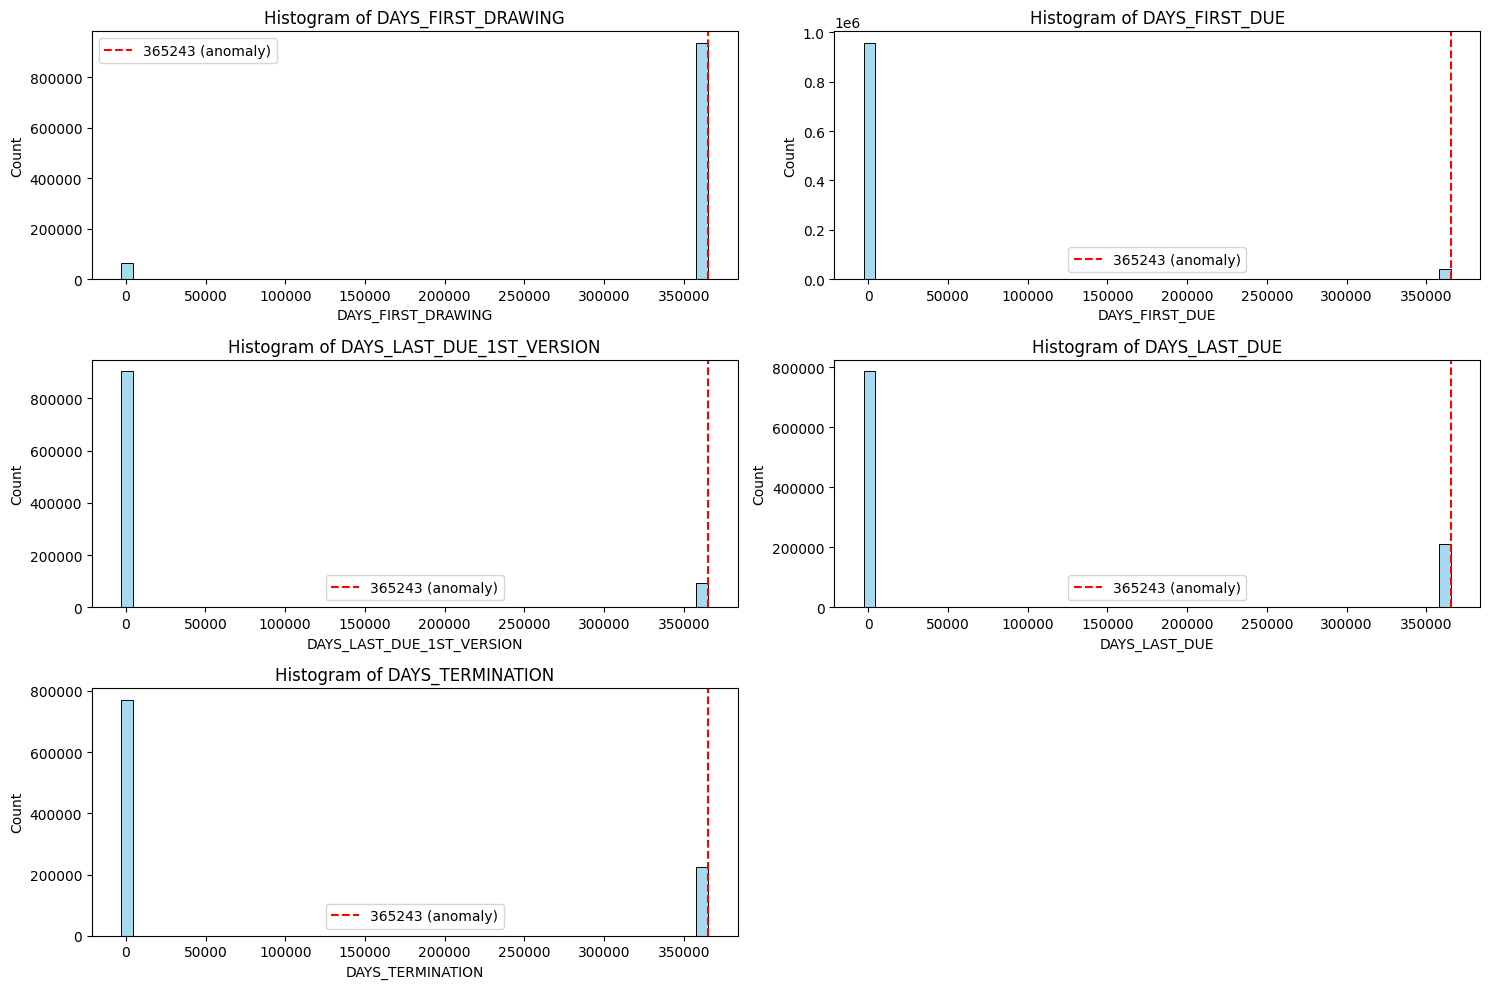

In [41]:
df = pd.read_csv('../input/previous_application.csv')
cols = [
    'DAYS_FIRST_DRAWING',
    'DAYS_FIRST_DUE',
    'DAYS_LAST_DUE_1ST_VERSION',
    'DAYS_LAST_DUE',
    'DAYS_TERMINATION'
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols):
    plt.subplot(3, 2, i+1)
    # Plot histogram excluding 365243
    sns.histplot(df[col], bins=50, kde=False, color='skyblue')
    
    # label for 365243 if it exists in the data
    if (df[col] == 365243).any():
        plt.axvline(365243, color='red', linestyle='--', label='365243 (anomaly)')
        plt.legend()
    
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Feature Engineering for Previous Applications Data

Since clients may have multiple past applications, we aggregate records at the **client level (`SK_ID_CURR`)** using descriptive statistics:

- **Mean, Sum** -> capture overall levels and total amounts  
- **Min, Max** -> highlight extremes (e.g., earliest, largest, longest)  
- **Variance** -> measure stability and fluctuations  
- **Proportions** -> quantify categorical outcomes (e.g., approval/refusal rates)

For **numerical variables**, we compute selected statistics such as min, max, mean, variance, and sum.  
For **categorical variables**, we calculate the proportion of each category to capture frequency information.


We further separate the aggregation by **application outcome (`NAME_CONTRACT_STATUS`)**, focusing mainly on **approved** and **refused** applications:

- **Approved applications** → represent loans or credit amounts actually granted, reflecting **real debt levels, repayment ability, loan usage, and credit preferences**.  
- **Refused applications** → represent credit demand that was not met, reflecting **application intent, frequency, requested amounts, and potential credit risk or borrowing pressure**.  

Separating these two groups avoids masking important differences.  
For example, a client may have applied for many loans but been refused for most of them. If aggregated together, the average loan amount might appear low, while in reality the client’s **credit demand is high**.

In [17]:
# Preprocess previous_applications.csv
def previous_applications(num_rows = None, nan_as_category = True):
    prev = pd.read_csv('../input/previous_application.csv', nrows = num_rows)
    prev, cat_cols = one_hot_encoder(prev, nan_as_category= True)
    # Days 365.243 values -> nan
    prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace= True)
    prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace= True)
    # Add feature: value ask / value received percentage
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']

    # Previous applications numeric features
    num_aggregations = {
        'AMT_ANNUITY': ['min', 'max', 'mean'],
        'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'],
        'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
        'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
        'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'DAYS_DECISION': ['min', 'max', 'mean'],
        'CNT_PAYMENT': ['mean', 'sum'],
    }

    # Previous applications categorical features
    cat_aggregations = {}
    for cat in cat_cols:
        cat_aggregations[cat] = ['mean']
    
    prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])

    # Previous Applications: Approved Applications - only numerical features
    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    approved_agg = approved.groupby('SK_ID_CURR').agg(num_aggregations)
    approved_agg.columns = pd.Index(['APPROVED_' + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
    prev_agg = prev_agg.join(approved_agg, how='left', on='SK_ID_CURR')
    
    # Previous Applications: Refused Applications - only numerical features
    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    refused_agg = refused.groupby('SK_ID_CURR').agg(num_aggregations)
    refused_agg.columns = pd.Index(['REFUSED_' + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
    prev_agg = prev_agg.join(refused_agg, how='left', on='SK_ID_CURR')
    del refused, refused_agg, approved, approved_agg, prev
    gc.collect()
    return prev_agg

In [18]:
prev = pd.read_csv('../input/previous_application.csv')
df = previous_applications()

When examining aggregated features from previous applications, we found that:  
- **Approved features** already contain many `NaN` values.  
- **Refused features** contain significantly more `NaN`s, indicating different information content.  
→ This reinforces the need to treat them separately.  

We also compared densities of four representative variables:  
- `AMT_APPLICATION_MEAN` -> average requested loan amount  
- `AMT_CREDIT_MEAN` -> average approved loan amount  
- `APP_CREDIT_PERC_MEAN` -> ratio of requested to approved amounts  
- `DAYS_DECISION_MEAN` -> average time of past loan decisions relative to current application  

The density plots show clear distributional differences between **approved** and **refused** applications, further supporting separate aggregation at the client level.


In [19]:
def find_columns_with_nan_and_count(df):
    nan_columns = df.columns[df.isnull().any()]  # filter columns with NaN
    nan_counts = df[nan_columns].isnull().sum()  # Calculate number of data with NaN 
    return nan_counts

def clip_nonzero_outliers(series, lower_quantile=0.01, upper_quantile=0.99):
    """Clip outliers for smoother density plots"""
    lower, upper = series.quantile([lower_quantile, upper_quantile])
    return series.clip(lower, upper)

Mean number of data with NaN（APPROVED_）：8550.033333333333
Mean number of data with NaN（REFUSED_）：238479.26666666666


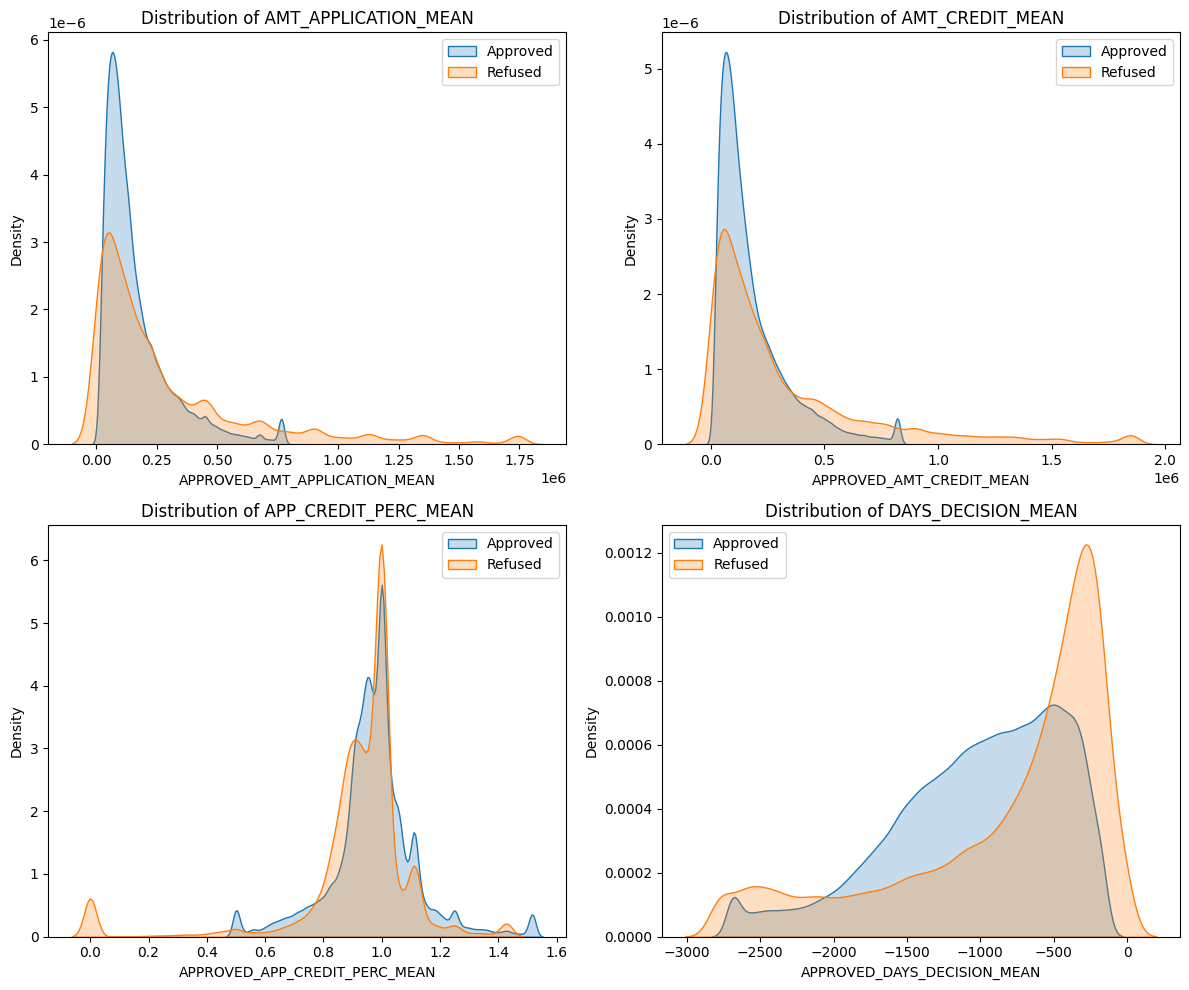

In [20]:
columns_with_nan = find_columns_with_nan_and_count(df)

approved_missing = columns_with_nan[columns_with_nan.index.str.startswith('APPROVED_')]
refused_missing = columns_with_nan[columns_with_nan.index.str.startswith('REFUSED_')]

approved_mean = approved_missing.mean()
refused_mean = refused_missing.mean()

print(f"Mean number of data with NaN（APPROVED_）：{approved_mean}")
print(f"Mean number of data with NaN（REFUSED_）：{refused_mean}")

features_to_plot = [
    'AMT_APPLICATION_MEAN',
    'AMT_CREDIT_MEAN',
    'APP_CREDIT_PERC_MEAN',
    'DAYS_DECISION_MEAN'
]

plt.figure(figsize=(12, 10))
for i, feat in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.kdeplot(
        clip_nonzero_outliers(df[f'APPROVED_{feat}']),
        label='Approved',
        fill=True
    )
    sns.kdeplot(
        clip_nonzero_outliers(df[f'REFUSED_{feat}']),
        label='Refused',
        fill=True
    )
    plt.title(f'Distribution of {feat}')
    plt.legend()
plt.tight_layout()
plt.show()

### Remaining Data Processing 
The remaining three datasets are:  
1. **`POS_CASH_balance.csv`** -> monthly repayment status of previous installment loans (POS or cash). Each row = one loan (`SK_ID_PREV`) in one month (`MONTHS_BALANCE`), including total installments, remaining terms, and days past due.  
2. **`installments_payments.csv`** -> actual installment payment records, with scheduled vs. actual payment dates and amounts, reflecting real repayment behavior.  
3. **`credit_card_balance.csv`** -> monthly balance and usage of credit card accounts, including balance, credit limit, and transaction frequency, showing credit utilization and liquidity.  

Each dataset contains multiple records per client (`SK_ID_CURR`), often across multiple loans (`SK_ID_PREV`) and months.

---

### Feature Engineering for Remaining Data
To transform these time-series and loan-level records into client-level features:  
- **Numerical variables** -> aggregated using descriptive statistics (min, max, mean, variance, sum).  
- **Categorical variables** -> aggregated as category proportions.  

This approach, consistent with earlier datasets, compresses detailed repayment and usage histories into **interpretable client-level features** that capture repayment patterns, credit utilization, and risk preferences.


In [21]:
# Preprocess POS_CASH_balance.csv
def pos_cash(num_rows = None, nan_as_category = True):
    pos = pd.read_csv('../input/POS_CASH_balance.csv', nrows = num_rows)
    pos, cat_cols = one_hot_encoder(pos, nan_as_category= True)
    # Features
    aggregations = {
        'MONTHS_BALANCE': ['max', 'mean', 'size'],
        'SK_DPD': ['max', 'mean'],
        'SK_DPD_DEF': ['max', 'mean']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    
    pos_agg = pos.groupby('SK_ID_CURR').agg(aggregations)
    pos_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
    # Count pos cash accounts
    pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
    del pos
    gc.collect()
    return pos_agg

In [22]:
# Preprocess installments_payments.csv
def installments_payments(num_rows = None, nan_as_category = True):
    ins = pd.read_csv('../input/installments_payments.csv', nrows = num_rows)
    ins, cat_cols = one_hot_encoder(ins, nan_as_category= True)
    # Percentage and difference paid in each installment (amount paid and installment value)
    ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    # Days past due and days before due (no negative values)
    ins['DPD'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
    ins['DBD'] = ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']
    ins['DPD'] = ins['DPD'].apply(lambda x: x if x > 0 else 0)
    ins['DBD'] = ins['DBD'].apply(lambda x: x if x > 0 else 0)
    # Features: Perform aggregations
    aggregations = {
        'NUM_INSTALMENT_VERSION': ['nunique'],
        'DPD': ['max', 'mean', 'sum','min','std' ],
        'DBD': ['max', 'mean', 'sum','min','std'],
        'PAYMENT_PERC': [ 'max','mean',  'var','min','std'],
        'PAYMENT_DIFF': [ 'max','mean', 'var','min','std'],
        'AMT_INSTALMENT': ['max', 'mean', 'sum','min','std'],
        'AMT_PAYMENT': ['min', 'max', 'mean', 'sum','std'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum','std']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    ins_agg = ins.groupby('SK_ID_CURR').agg(aggregations)
    ins_agg.columns = pd.Index(['INSTAL_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    # Count installments accounts
    ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()
    del ins
    gc.collect()
    return ins_agg

In [23]:
def convert_bool_to_int(df):
    bool_columns = df.select_dtypes(include=['bool']).columns
    df[bool_columns] = df[bool_columns].astype(int)
    return df

In [24]:
# Preprocess credit_card_balance.csv
def credit_card_balance(num_rows = None, nan_as_category = True):
    cc = pd.read_csv('../input/credit_card_balance.csv', nrows = num_rows)
    cc, cat_cols = one_hot_encoder(cc, nan_as_category= True)
    # General aggregations
    cc.drop(['SK_ID_PREV'], axis= 1, inplace = True)
    for column in cc.columns:
        if cc[column].dtype == 'object':  # 对于离散型特征
            cc[column].fillna(cc[column].mode()[0], inplace=True)  # 使用众数填充
        else:  # 对于连续型特征
            cc[column].fillna(cc[column].median(), inplace=True)  # 使用中位数填充
    cc_agg = cc.groupby('SK_ID_CURR').agg([ 'max', 'mean', 'sum', 'var'])
    cc_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
    # Count credit card lines
    cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()
    cc_agg = convert_bool_to_int(cc_agg)
    del cc
    gc.collect()
    return cc_agg

## Train LightGBM with the Extracted Features

We combined all the previously processed data to form a new dataset that integrates the aggregated information from all sources. This consolidated dataset will be used to train the LightGBM model.

In [25]:
def handle_missing_values(df, threshold=10):
    """
    统计每列的缺失值数量和比例，并删除缺失值比例大于指定阈值的列。

    Args:
        df (pd.DataFrame): 输入的 DataFrame。
        threshold (float): 缺失值比例的阈值（百分比），大于此值的列将被删除。

    Returns:
        pd.DataFrame: 处理后的 DataFrame。
    """
    # 统计每列的缺失值数量和比例
    nan_info = df.isnull().sum().to_frame(name='NaN Count')
    nan_info['NaN Percentage'] = (nan_info['NaN Count'] / len(df)) * 100

    # 显示所有有缺失值的列
    nan_info = nan_info[nan_info['NaN Count'] > 0].sort_values(by='NaN Count', ascending=False)
    print("Columns with NaN values:\n", nan_info)

    # 绘制缺失值分布图
    nan_info['NaN Percentage'].plot(kind='bar', figsize=(10, 6), title='NaN Percentage by Column')
    plt.ylabel('Percentage')
    plt.show()

    # 删除缺失值比例大于阈值的列
    columns_to_drop = nan_info[nan_info['NaN Percentage'] > threshold].index
    df_cleaned = df.drop(columns=columns_to_drop)

    print(f"Deleted columns (NaN > {threshold}%): {list(columns_to_drop)}")
    print(f"Remaining columns: {df_cleaned.shape[1]}")

    return df_cleaned

In [43]:
def data_prepare(change=None, debug=False):
    if change is None:
        df = pd.read_csv('../input/application_train.csv')
        for col in df.select_dtypes(include=['object']).columns:
            try:
                df[col] = df[col].astype(float)
            except ValueError:
                print(f"Column {col} cannot be converted to float and will be skipped.")
        return df
    num_rows = 1000 if debug else None
    df = application_train_test_for_model(num_rows)
    with timer("Process bureau and bureau_balance"):
        bureau = bureau_and_balance(num_rows)
        print("Bureau df shape:", bureau.shape)
        df = df.join(bureau, how='left', on='SK_ID_CURR')
        del bureau
        gc.collect()
    with timer("Process previous_applications"):
        prev = previous_applications(num_rows)
        print("Previous applications df shape:", prev.shape)
        df = df.join(prev, how='left', on='SK_ID_CURR')
        del prev
        gc.collect()
    with timer("Process POS-CASH balance"):
        pos = pos_cash(num_rows)
        print("Pos-cash balance df shape:", pos.shape)
        df = df.join(pos, how='left', on='SK_ID_CURR')
        del pos
        gc.collect()
    with timer("Process installments payments"):
        ins = installments_payments(num_rows)
        print("Installments payments df shape:", ins.shape)
        df = df.join(ins, how='left', on='SK_ID_CURR')
        del ins
        gc.collect()
    with timer("Process credit card balance"):
        cc = credit_card_balance(num_rows)
        print("Credit card balance df shape:", cc.shape)
        df = df.join(cc, how='left', on='SK_ID_CURR')
        del cc
        gc.collect()
        
    # df = handle_missing_values(df, threshold=80)
    # df.to_csv(f'../input/processed_data.csv', index=False)
    return df

We train the dataset using **LightGBM with K-Fold cross-validation**:

- **Data Split**: divide `df` into training and test sets, adjust column names to avoid errors.  
- **K-Fold Process**: in each fold, split into training/validation sets, compute class balance, define the LightGBM model, train, validate, and save predictions and feature importance.  
- **Model Setup**: use **GOSS (Gradient-based One-Side Sampling)** for efficient sampling, and apply **class weight balancing** to handle the strong imbalance between `TARGET=0` and `TARGET=1`.  
- **Evaluation & Output**: compute overall AUC on training samples, generate test predictions for submission, and visualize feature importance.


In [45]:
df = data_prepare(change=True, debug=False)

Train samples: 307511, test samples: 48744
Bureau df shape: (305811, 107)
Process bureau and bureau_balance - done in 10s
Previous applications df shape: (338857, 249)
Process previous_applications - done in 8s
Pos-cash balance df shape: (337252, 18)
Process POS-CASH balance - done in 5s
Installments payments df shape: (339587, 36)
Process installments payments - done in 13s
Credit card balance df shape: (103558, 113)
Process credit card balance - done in 7s


After data processing, we ultimately obtained 773 data features.

In [46]:
df.shape

(356251, 773)

In [47]:
df_train = df[df['TARGET'].notnull()]
df_test = df[df['TARGET'].isnull()]
print(f"Training samples: {len(df_train)}, Trainning dataset ratio: {len(df_train)/(len(df_train) + len(df_test))}, Testing samples: {len(df_test)}, Testing dataset ratio: {len(df_test)/(len(df_train) + len(df_test))}") 

Training samples: 307507, Trainning dataset ratio: 0.8631751209119413, Testing samples: 48744, Testing dataset ratio: 0.1368248790880587


### Model training before other feature generation and selection

Please note that the model has already been trained. To facilitate subsequent evaluations, we have saved the model weights. If the load parameter is set to True, the pre-trained model will be loaded directly

In [48]:
def kfold_lightgbm(df, num_folds, submission_file_name, prefix, stratified=False, debug=False, load=False):


    path = os.getcwd()
    os.makedirs(prefix, exist_ok=True)
    os.chdir(prefix)
    
    train_df = df[df['TARGET'].notnull()]
    test_df = df[df['TARGET'].isnull()]
    
    train_df.columns = ["".join(c if c.isalnum() else "_" for c in str(x)) for x in train_df.columns]
    test_df.columns  = ["".join(c if c.isalnum() else "_" for c in str(x)) for x in test_df.columns]
    
    print(f"Starting LightGBM. Train shape: {train_df.shape}, test shape: {test_df.shape}")
    del df
    gc.collect()
    
    folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=47) if stratified else \
            KFold(n_splits=num_folds, shuffle=True, random_state=47)
    
    oof_preds = np.zeros(train_df.shape[0])
    sub_preds = np.zeros(test_df.shape[0])
    feature_importance_df = pd.DataFrame()
    feats = [f for f in train_df.columns if f not in ['TARGET', 'SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV', 'index']]
    train_auc, valid_auc = [], []
    
    lgb_params = dict(
        boosting_type='goss',
        nthread=4,
        n_estimators=10000,
        learning_rate=0.005134,
        num_leaves=54,
        colsample_bytree=0.508716,
        subsample=1,
        max_depth=10,
        reg_alpha=0.436193,
        reg_lambda=0.479169,
        min_split_gain=0.024766,
        min_child_weight=40,
        silent=-1,
        verbose=-1,
        is_unbalance=False
    )


    for n_fold, (train_idx, valid_idx) in enumerate(folds.split(train_df[feats], train_df['TARGET'])):
        model_filename = f"{prefix}_lightgbm_fold_{n_fold + 1}.txt"
        print(f"\n=== Fold {n_fold + 1}/{num_folds} ===")

        X_train, y_train = train_df[feats].iloc[train_idx], train_df['TARGET'].iloc[train_idx]
        X_valid, y_valid = train_df[feats].iloc[valid_idx], train_df['TARGET'].iloc[valid_idx]
        print(X_valid.shape)
        print(X_train.shape)

        if load:
            # *********** loading model ***********
            if not os.path.exists(model_filename):
                raise FileNotFoundError(f"Model file {model_filename} does not exist!")

            print(f"Loading model from {model_filename}")
            booster = lgb.Booster(model_file=model_filename)

            # 预测
            oof_preds[valid_idx] = booster.predict(X_valid, num_iteration=booster.best_iteration, predict_disable_shape_check=True)
            sub_preds += booster.predict(test_df[feats], num_iteration=booster.best_iteration) / folds.n_splits

            # 计算 AUC
            train_auc_fold = roc_auc_score(y_train, booster.predict(X_train, num_iteration=booster.best_iteration))
            valid_auc_fold = roc_auc_score(y_valid, oof_preds[valid_idx])
            train_auc.append(train_auc_fold)
            valid_auc.append(valid_auc_fold)


            print(f"Loaded model Fold {n_fold + 1}: Train AUC={train_auc_fold:.6f}, Valid AUC={valid_auc_fold:.6f}")


            fold_importance_df = pd.DataFrame({
                "feature": booster.feature_name(),
                "importance": booster.feature_importance(importance_type='gain'),
                "fold": n_fold + 1
            })

        else:
            # *********** training model ***********
            clf = LGBMClassifier(**lgb_params)
            clf.fit(
                X_train, y_train,
                eval_set=[(X_train, y_train), (X_valid, y_valid)],
                eval_metric='auc',
                verbose=1000,
                early_stopping_rounds=200
            )


            clf.booster_.save_model(model_filename)
            print(f"Model saved as {model_filename}")


            evals_result = clf.evals_result_
            best_iteration = clf.best_iteration_
            train_auc_fold = evals_result['training']['auc'][best_iteration - 1]
            valid_auc_fold = evals_result['valid_1']['auc'][best_iteration - 1]
            train_auc.append(train_auc_fold)
            valid_auc.append(valid_auc_fold)


            oof_preds[valid_idx] = clf.predict_proba(X_valid, num_iteration=best_iteration)[:, 1]
            sub_preds += clf.predict_proba(test_df[feats], num_iteration=best_iteration)[:, 1] / folds.n_splits


            fold_importance_df = pd.DataFrame({
                "feature": feats,
                "importance": clf.feature_importances_,
                "fold": n_fold + 1
            })

            print(f"Trained Fold {n_fold + 1}: Train AUC={train_auc_fold:.6f}, Valid AUC={valid_auc_fold:.6f}")

        feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)


        print("Fold %2d AUC : %.6f" % (n_fold + 1, roc_auc_score(y_valid, oof_preds[valid_idx])))


    full_auc = roc_auc_score(train_df['TARGET'], oof_preds)
    print(f"\nFull OOF AUC: {full_auc:.6f}")

    if not debug:
        test_df['TARGET'] = sub_preds
        test_df[['SK_ID_CURR', 'TARGET']].to_csv(submission_file_name, index=False)
        print(f"Submission saved as {submission_file_name}")


    auc_df = pd.DataFrame({
        'Fold': range(1, len(train_auc) + 1),
        'Train AUC': train_auc,
        'Validation AUC': valid_auc
    })
    auc_filename = f"{prefix}_auc_results.csv"
    auc_df.to_csv(auc_filename, index=False)
    print(f"AUC results saved as {auc_filename}")


    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_auc) + 1), train_auc, marker='o', label='Train AUC', color='blue')
    plt.plot(range(1, len(valid_auc) + 1), valid_auc, marker='o', label='Validation AUC', color='orange')
    plt.title('Train vs Validation AUC', fontsize=14)
    plt.xlabel('Fold', fontsize=12)
    plt.ylabel('AUC', fontsize=12)
    plt.legend()
    plt.grid(True)
    plot_filename = f"{prefix}_train_validation_auc.png"
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"AUC plot saved as {plot_filename}")


    os.chdir(path)
    return feature_importance_df


In [ ]:
os.chdir('/home/rcy/rcy_old_backup/5470/code')
submission_file_name = "LightGBM_initial.csv"
with timer("Result Collecting"):
    feature_importance = kfold_lightgbm(df, num_folds=5, submission_file_name=submission_file_name, prefix='initial', stratified=True, debug=False, load=True)

Starting LightGBM. Train shape: (307507, 773), test shape: (48744, 773)

=== Fold 1/5 ===


(61502, 770)
(246005, 770)
Loading model from initial_lightgbm_fold_1.txt
Loaded model Fold 1: Train AUC=0.911211, Valid AUC=0.793811
Fold  1 AUC : 0.793811

=== Fold 2/5 ===
(61502, 770)
(246005, 770)
Loading model from initial_lightgbm_fold_2.txt
Loaded model Fold 2: Train AUC=0.927503, Valid AUC=0.794757
Fold  2 AUC : 0.794757

=== Fold 3/5 ===
(61501, 770)
(246006, 770)
Loading model from initial_lightgbm_fold_3.txt
Loaded model Fold 3: Train AUC=0.921715, Valid AUC=0.795640
Fold  3 AUC : 0.795640

=== Fold 4/5 ===
(61501, 770)
(246006, 770)
Loading model from initial_lightgbm_fold_4.txt
Loaded model Fold 4: Train AUC=0.911068, Valid AUC=0.794647
Fold  4 AUC : 0.794647

=== Fold 5/5 ===
(61501, 770)
(246006, 770)
Loading model from initial_lightgbm_fold_5.txt


We uploaded the results to Kaggle for evaluation:
- **Private Score**: 0.79076
- **Public Score**: 0.79595

#### Baseline Compare

To benchmark the main LightGBM model, we trained a **Random Forest classifier** as a baseline:  
- Parameters: `n_estimators=100`, `random_state=50`  
- Missing values handled by **median imputation** before training  
- Predictions from this model served as a **performance benchmark** against LightGBM


In [ ]:
def dataset_preprocess(df):
    df_copy = df.copy()
    df_copy.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    return df_copy

In [ ]:
df_copy = dataset_preprocess(df)

df_train = df_copy[df_copy['TARGET'].notnull()]
df_test = df_copy[df_copy['TARGET'].isnull()]
if 'TARGET' in df_train:
    train = df_train.drop(columns = ['TARGET'])
else:
    train = df_train.copy()
    
train = df_train.drop(columns = ['TARGET'])
train_labels = df_train['TARGET']
# # Feature names
features = list(train.columns)

test = df_test.copy().drop(columns = ['TARGET'])

# Make the random forest classifier
random_forest = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)

# Train on the training data
random_forest.fit(train, train_labels)

# Extract feature importances
feature_importance_values = random_forest.feature_importances_
feature_importances = pd.DataFrame({'feature': features, 'importance': feature_importance_values})

# Make predictions on the test data
predictions = random_forest.predict_proba(test)[:, 1]
# Make a submission dataframe
submit = df_test[['SK_ID_CURR']]
submit['TARGET'] = predictions

# Save the submission dataframe
submit.to_csv('random_forest_baseline.csv', index = False)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 384 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 out of 100 | elapsed:    8.5s remaining:   12.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   10.3s finished
[Parallel(n_jobs=100)]: Using backend ThreadingBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   2 out of 100 | elapsed:    0.0s remaining:    2.1s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed:    0.1s finished
/tmp/ipykernel_856874/1377135186.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submit['TARGET'] = predictions


Upload the results of random foreat to Kaggle for evaluation, and the outcomes:
- **Private Score**: 0.70981
- **Public Score**: 0.70396

### Other feature generation and selection

Now that we have dealt with the categorical variables and the outliers, let's continue with the EDA.
#### Correlations
we examine correlations between features and the target.  
Using pandas `.corr()` method, we calculate the Pearson correlation coefficient for each feature with respect to the target.

In [ ]:
df_train = df[df['TARGET'].notnull()]

In [ ]:
df_train = df[df['TARGET'].notnull()]
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns  # 筛选数值列
numeric_cols = numeric_cols.drop('TARGET')  # 排除 TARGET 列本身
correlations = df_train[numeric_cols].corrwith(df_train['TARGET']).sort_values()

# 显示结果
print('\nMost Negative Correlations:\n', correlations.head(15))


Most Negative Correlations:
 NEW_EXT_SOURCES_MEAN                      -0.222054
NEW_SOURCES_PROD                          -0.188556
EXT_SOURCE_3                              -0.178926
EXT_SOURCE_2                              -0.160471
EXT_SOURCE_1                              -0.155317
BURO_MONTHS_BALANCE_SIZE_MEAN             -0.080193
BURO_CREDIT_ACTIVE_Closed_MEAN            -0.079369
PREV_CODE_REJECT_REASON_XAP_MEAN          -0.073938
ACTIVE_MONTHS_BALANCE_SIZE_MEAN           -0.065154
PREV_NAME_CONTRACT_STATUS_Approved_MEAN   -0.063526
CC_COUNT                                  -0.060481
CC_NAME_CONTRACT_STATUS_Active_SUM        -0.059376
CC_MONTHS_BALANCE_VAR                     -0.058817
INSTAL_DAYS_ENTRY_PAYMENT_STD             -0.058416
CLOSED_MONTHS_BALANCE_SIZE_MEAN           -0.058354
dtype: float64


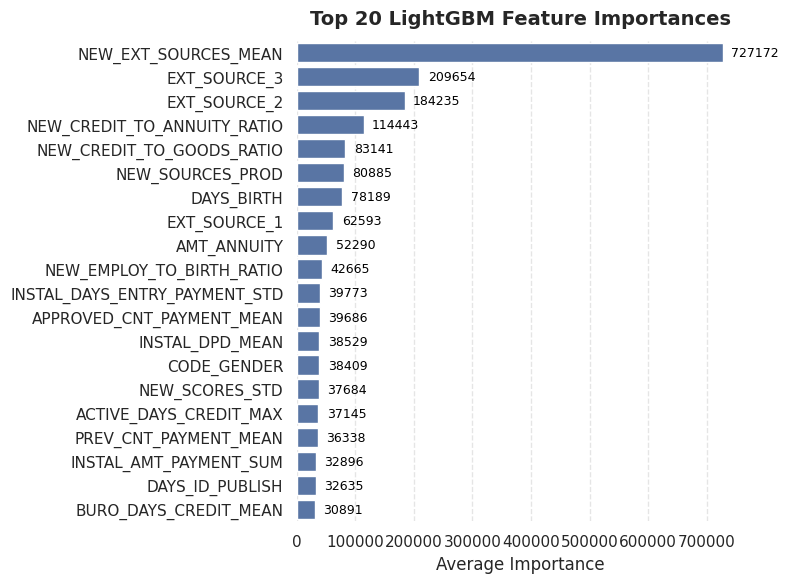

In [ ]:

def display_importances(feature_importance_df_, top_n=20, save_path=None):

    # 聚合并排序
    feature_grouped = (
        feature_importance_df_[["feature", "importance"]]
        .groupby("feature")
        .mean()
        .sort_values(by="importance", ascending=False)
        .reset_index()
    )

    # 前 top_n 特征
    top_features = feature_grouped.head(top_n)

    # 保持默认 seaborn 风格
    sns.set(style="whitegrid")

    plt.figure(figsize=(8, max(6, top_n * 0.25)))
    
    # 使用默认配色（蓝绿色调）
    ax = sns.barplot(
        x="importance",
        y="feature",
        data=top_features,
        order=top_features["feature"],  # 保持从高到低顺序
        orient="h"
    )

    # 在条形右侧显示 importance 数字
    for i, value in enumerate(top_features["importance"]):
        ax.text(
            value + 0.02 * top_features["importance"].max(),
            i,
            f"{value:.0f}",
            color="black",
            va="center",
            fontsize=9
        )

    # 标题与标签
    plt.title(f"Top {top_n} LightGBM Feature Importances", fontsize=14, weight="bold", pad=12)
    plt.xlabel("Average Importance", fontsize=12)
    plt.ylabel("")
    plt.grid(axis='x', linestyle="--", alpha=0.5)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()

    # 保存或显示
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Feature importance plot saved as {save_path}")
    else:
        plt.show()
display_importances(feature_importance)

#### Polynomial Feature Expansion

Based on the correlation analysis, we selected the four features most strongly associated with the target:  
**`EXT_SOURCE_1`**, **`EXT_SOURCE_2`**, **`EXT_SOURCE_3`**, and **`DAYS_BIRTH`**.  

To capture potential nonlinear relationships among these key variables, we generated **third-degree polynomial features**. This expansion enables the model to learn complex interactions, thereby improving predictive stability and accuracy.  

The workflow was as follows:
- Split the dataset into training and testing sets according to whether `TARGET` is missing.  
- Impute missing values using the median.  
- Apply `PolynomialFeatures` (degree = 3) to create polynomial and interaction terms.  
- Re-merge the expanded features with the original dataset using `SK_ID_CURR` to maintain structural consistency.  

The final dataset combines both the original features and the newly generated polynomial features, providing a richer representation for model training.


In [ ]:
def create_polynomial_features(df: pd.DataFrame):
    # Split the data into training and testing sets
    train_df = df[df['TARGET'].notnull()]
    test_df = df[df['TARGET'].isnull()]

    # Prepare dataframes for polynomial features
    poly_features = train_df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
    poly_features_test = test_df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

    # Impute missing values with median
    imputer = SimpleImputer(missing_values=np.nan, strategy='median')
    poly_target = poly_features['TARGET']
    poly_features = poly_features.drop(columns=['TARGET'])

    # Impute the features
    poly_features = imputer.fit_transform(poly_features)
    poly_features_test = imputer.transform(poly_features_test)

    # Create polynomial features up to degree 3
    poly_transformer = PolynomialFeatures(degree=3)
    poly_features = poly_transformer.fit_transform(poly_features)
    poly_features_test = poly_transformer.transform(poly_features_test)

    # Create a dataframe for the polynomial features
    poly_features = pd.DataFrame(poly_features,
                                 columns=poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']))

    # Add target back to the training polynomial features
    poly_features['TARGET'] = poly_target

    # Correlation analysis with the target
    poly_corrs = poly_features.corr()['TARGET'].sort_values()
    # print(poly_corrs.head(10))  # Most negative correlations
    # print(poly_corrs.tail(5))    # Most positive correlations

    # Create and merge polynomial features back to training dataframe
    poly_features['SK_ID_CURR'] = train_df['SK_ID_CURR'].astype(float)
    poly_features.drop(columns=['TARGET'], inplace=True)
    
    app_train_poly = train_df.merge(poly_features, on='SK_ID_CURR', how='left')

    # Merging test features
    poly_features_test = pd.DataFrame(poly_features_test, columns=poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']))
    poly_features_test['SK_ID_CURR'] = test_df['SK_ID_CURR']
    app_test_poly = test_df.merge(poly_features_test, on='SK_ID_CURR', how='left')

    # Aligning the training and test dataframes
    app_train_poly, app_test_poly = app_train_poly.align(app_test_poly, join='inner', axis=1)
    
    combined_df = pd.concat([app_train_poly, app_test_poly], ignore_index=True)
    # Returning the training and testing dataframes with polynomial features
    return combined_df

# Example usage:
combined_df = create_polynomial_features(df)

We try to use more features to train the model again.

Starting LightGBM. Train shape: (307507, 829), test shape: (48744, 829)

=== Fold 1/5 ===
Loading model from poly_feature_lightgbm_fold_1.txt
Loaded model Fold 1: Train AUC=0.921147, Valid AUC=0.793160
Fold  1 AUC : 0.793160

=== Fold 2/5 ===
Loading model from poly_feature_lightgbm_fold_2.txt
Loaded model Fold 2: Train AUC=0.911443, Valid AUC=0.793732
Fold  2 AUC : 0.793732

=== Fold 3/5 ===
Loading model from poly_feature_lightgbm_fold_3.txt
Loaded model Fold 3: Train AUC=0.924435, Valid AUC=0.795455
Fold  3 AUC : 0.795455

=== Fold 4/5 ===
Loading model from poly_feature_lightgbm_fold_4.txt
Loaded model Fold 4: Train AUC=0.906100, Valid AUC=0.793861
Fold  4 AUC : 0.793861

=== Fold 5/5 ===
Loading model from poly_feature_lightgbm_fold_5.txt
Loaded model Fold 5: Train AUC=0.892822, Valid AUC=0.789121
Fold  5 AUC : 0.789121

Full OOF AUC: 0.793057
Submission saved as LightGBM_with_polynomial_features.csv
AUC results saved as poly_feature_auc_results.csv


/tmp/ipykernel_977243/373596682.py:148: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['TARGET'] = sub_preds


AUC plot saved as poly_feature_train_validation_auc.png


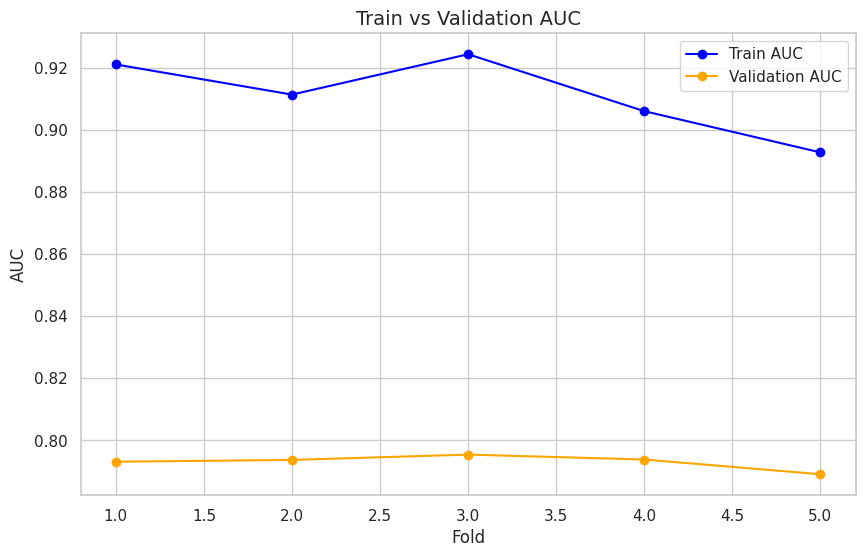

In [ ]:
submission_file_name = "LightGBM_with_polynomial_features.csv"
ploy_feature_importance = kfold_lightgbm(combined_df, num_folds=5, submission_file_name=submission_file_name, prefix='poly_feature', stratified=True, debug=False, load=True)

And the Kaggle scores are:
- **Private Score**: 0.78978
- **Public Score**: 0.79510

- Polynomial feature expansion did not significantly improve model performance.  
- LightGBM already captures nonlinearities and feature interactions, while polynomial expansion mainly added dimensionality and noise, offering no gain in generalization.  
- Feature importance results remained highly consistent with those before adding polynomial features, indicating little impact on the model’s decision basis.


In [ ]:
display_importances(ploy_feature_importance)

NameError: name 'ploy_feature_importance' is not defined

#### Feature Selection by Variance Threshold

To reduce redundant features, improve training efficiency, and lower computational cost,  
we filtered out features with variance less than **0.0001**.  
The remaining features were then used for model training.


In [ ]:
def dataset_preprocess(df):
    df_copy = df.copy()
    df_copy.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df_copy

In [ ]:
def variance_selection(df, target_column, variance_threshold=0.01):
    """
    使用方差选择法选择特征.

    Args:
        df (pd.DataFrame): 输入 DataFrame.
        target_column (str): 目标变量的列名.
        variance_threshold (float): 方差阈值.

    Returns:
        pd.DataFrame: 选择后的特征 DataFrame.
    """
    # 1. 复制原始 DataFrame
    df_copy = dataset_preprocess(df)
    
    # 2. 填充缺失值（这里选择使用中位数填充）
    imputer = SimpleImputer(missing_values=np.nan, strategy='median')
    X_filled = imputer.fit_transform(df_copy.drop(columns=[target_column]))

    # 3. 使用 VarianceThreshold 进行方差选择
    selector = VarianceThreshold(threshold=variance_threshold)
    X_transformed = selector.fit_transform(X_filled)

    # 4. 获取选中的特征
    selected_features = df_copy.drop(columns=[target_column]).columns[selector.get_support()]

    # 5. 从原始 DataFrame 中选择对应的特征数据
    df_selected = df[selected_features]
    df_selected['TARGET'] = df['TARGET']
    return df_selected

df_after_variance_selection = variance_selection(df, target_column='TARGET', variance_threshold=0.0001)

/tmp/ipykernel_977243/1758382937.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['TARGET'] = df['TARGET']


In [ ]:
df_after_variance_selection.shape

(356251, 695)

In [ ]:
os.chdir('/home/rcy/rcy_old_backup/5470/code')
submission_file_name = "LightGBM_variance_selection.csv"

variance_feature_importance = kfold_lightgbm(df_after_variance_selection, num_folds=5, submission_file_name=submission_file_name, prefix='ploy_variance', stratified=True, debug=False, load=True)

Starting LightGBM. Train shape: (307507, 695), test shape: (48744, 695)

=== Fold 1/5 ===
(61502, 692)
(246005, 692)
Loading model from ploy_variance_lightgbm_fold_1.txt
Loaded model Fold 1: Train AUC=0.926431, Valid AUC=0.794326
Fold  1 AUC : 0.794326

=== Fold 2/5 ===
(61502, 692)
(246005, 692)
Loading model from ploy_variance_lightgbm_fold_2.txt
Loaded model Fold 2: Train AUC=0.911536, Valid AUC=0.794668
Fold  2 AUC : 0.794668

=== Fold 3/5 ===
(61501, 692)
(246006, 692)
Loading model from ploy_variance_lightgbm_fold_3.txt
Loaded model Fold 3: Train AUC=0.882285, Valid AUC=0.912757
Fold  3 AUC : 0.912757

=== Fold 4/5 ===
(61501, 692)
(246006, 692)
Loading model from ploy_variance_lightgbm_fold_4.txt


[LightGBM] [Fatal] The number of features in data (692) is not the same as it was in training data (747).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.


LightGBMError: The number of features in data (692) is not the same as it was in training data (747).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

The Kaggle scores:
- **Private Score**: 0.79030
- **Public Score**: 0.79550

From the results, we can see that the number of features was reduced from 747 to 692, while the AUC score remained almost unchanged, decreasing slightly from 0.79595 to 0.79550.